                                           Disease Prediction using Machine Learning
                                                                             Aeman Muzaffar Shumi 04.03.2026

1. Project Overview

The goal is to build a machine learning model that helps doctors diagnose illnesses early by analyzing a patient's symptoms. By training the system on a large dataset of symptoms and their matching diseases, the model learns to spot patterns and predict what might be making a patient sick.

2. Problem Statement

In  the morden healthcare systems, hospital and clinics  are over corded , long patient wait times, lees Dr, 
medical staff. Paints come for  compalen bout the thier problem to Dr. and Dr. check
manually cross-referencing a patient's self-reported symptoms for finalaized the diease.
as well as  takes time nhuman error and cost for all medical test. 

Disease Prediction using Machine Learning with symptoms prognosis connect the model to real-world. 


3. Dataset Description

Dataset Source: Kaggle,    https://www.kaggle.com/datasets/kaushil268/disease-prediction-using-machine-learning?resource=download
               
Dataset Name: Disease Prediction Using Machine Learning
The dataset contains symptom-based records associated with specific diseases.

Dataset Characteristics
Attribute	Description
Number of Features	132 symptoms
Target Variable	prognosis (disease name)
Feature Type	Binary (0 = absent, 1 = present)
Dataset Files	Training.csv, Testing.csv


Example Features
itching
skin_rash
headache
nausea
vomiting
fatigue
high_fever
Target Variable

The prognosis column represents the diagnosed disease for each symptom combination.

4. Project Workflow 


The machine learning workflow follows the standard data science pipeline.

i)Data Loading
ii)Data Cleaning
iii)Exploratory Data Analysis (EDA)
iv)Feature Preparation
v)Model Training
vi)Model Evaluation
vii)Hyperparameter Tuning


In [613]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay

5. Data Loading

In [614]:
train_df = pd.read_csv(r"C:\Users\amena\DSI\Disease_Prediction_With_ML\data\Training.csv")
test_df = pd.read_csv(r"C:\Users\amena\DSI\Disease_Prediction_With_ML\data\Testing.csv")

The training dataset is used to train the models, while the testing dataset evaluates model performance.

6. Exploratory Data Analysis (EDA)

In [615]:
print(train_df.shape)
print(test_df.shape)

(4920, 134)
(42, 133)


In [616]:
train_df.head(5)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [617]:
test_df.head(5)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Allergy
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,GERD
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Chronic cholestasis
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Drug Reaction


In [618]:
print(train_df.columns)
print(test_df.columns)

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis',
       'Unnamed: 133'],
      dtype='str', length=134)
Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'blackheads', 'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis'],
      dtype='str', length=133)


In [619]:
print("Number of symptoms:", train_df.shape[1] - 1)
print("Number of unique diseases:", train_df['prognosis'].nunique())

Number of symptoms: 133
Number of unique diseases: 41


In [620]:
# is they are balance the split data?
print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 4920
Test size: 42


In [621]:
# data type
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), str(1)
memory usage: 5.0 MB


In [622]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Columns: 133 entries, itching to prognosis
dtypes: int64(132), str(1)
memory usage: 43.8 KB


In [623]:
train_df.select_dtypes(include="object").columns

Index(['prognosis'], dtype='str')

In [624]:
train_df["prognosis"].value_counts()

prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hep

In [625]:
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())

4616
0


In [626]:
train_df.isna().sum().sum()
test_df.isna().sum().sum()

np.int64(0)

In [627]:
train_df.isnull().sum()  #missing value

itching                    0
skin_rash                  0
nodal_skin_eruptions       0
continuous_sneezing        0
shivering                  0
                        ... 
blister                    0
red_sore_around_nose       0
yellow_crust_ooze          0
prognosis                  0
Unnamed: 133            4920
Length: 134, dtype: int64

In [628]:
test_df.isnull().sum()

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64

7. Data Cleaning

During preprocessing  unnecessary columns were remove

In [629]:
if train_df.isna().values.any():
    print("NaN values found")
else:
    print("No NaN values")

NaN values found


In [630]:
# Clean unnecessary like - Unnamed: 133  clomns
train_df.drop(columns=train_df.filter(regex="^Unnamed").columns, inplace=True)
test_df.drop(columns=test_df.filter(regex="^Unnamed").columns, inplace=True)

In [631]:
print(train_df.columns.str.contains("Unnamed").any())

False


In [632]:
# after unnamed is droped the train data set
print(train_df.shape)
print(test_df.shape)

(4920, 133)
(42, 133)


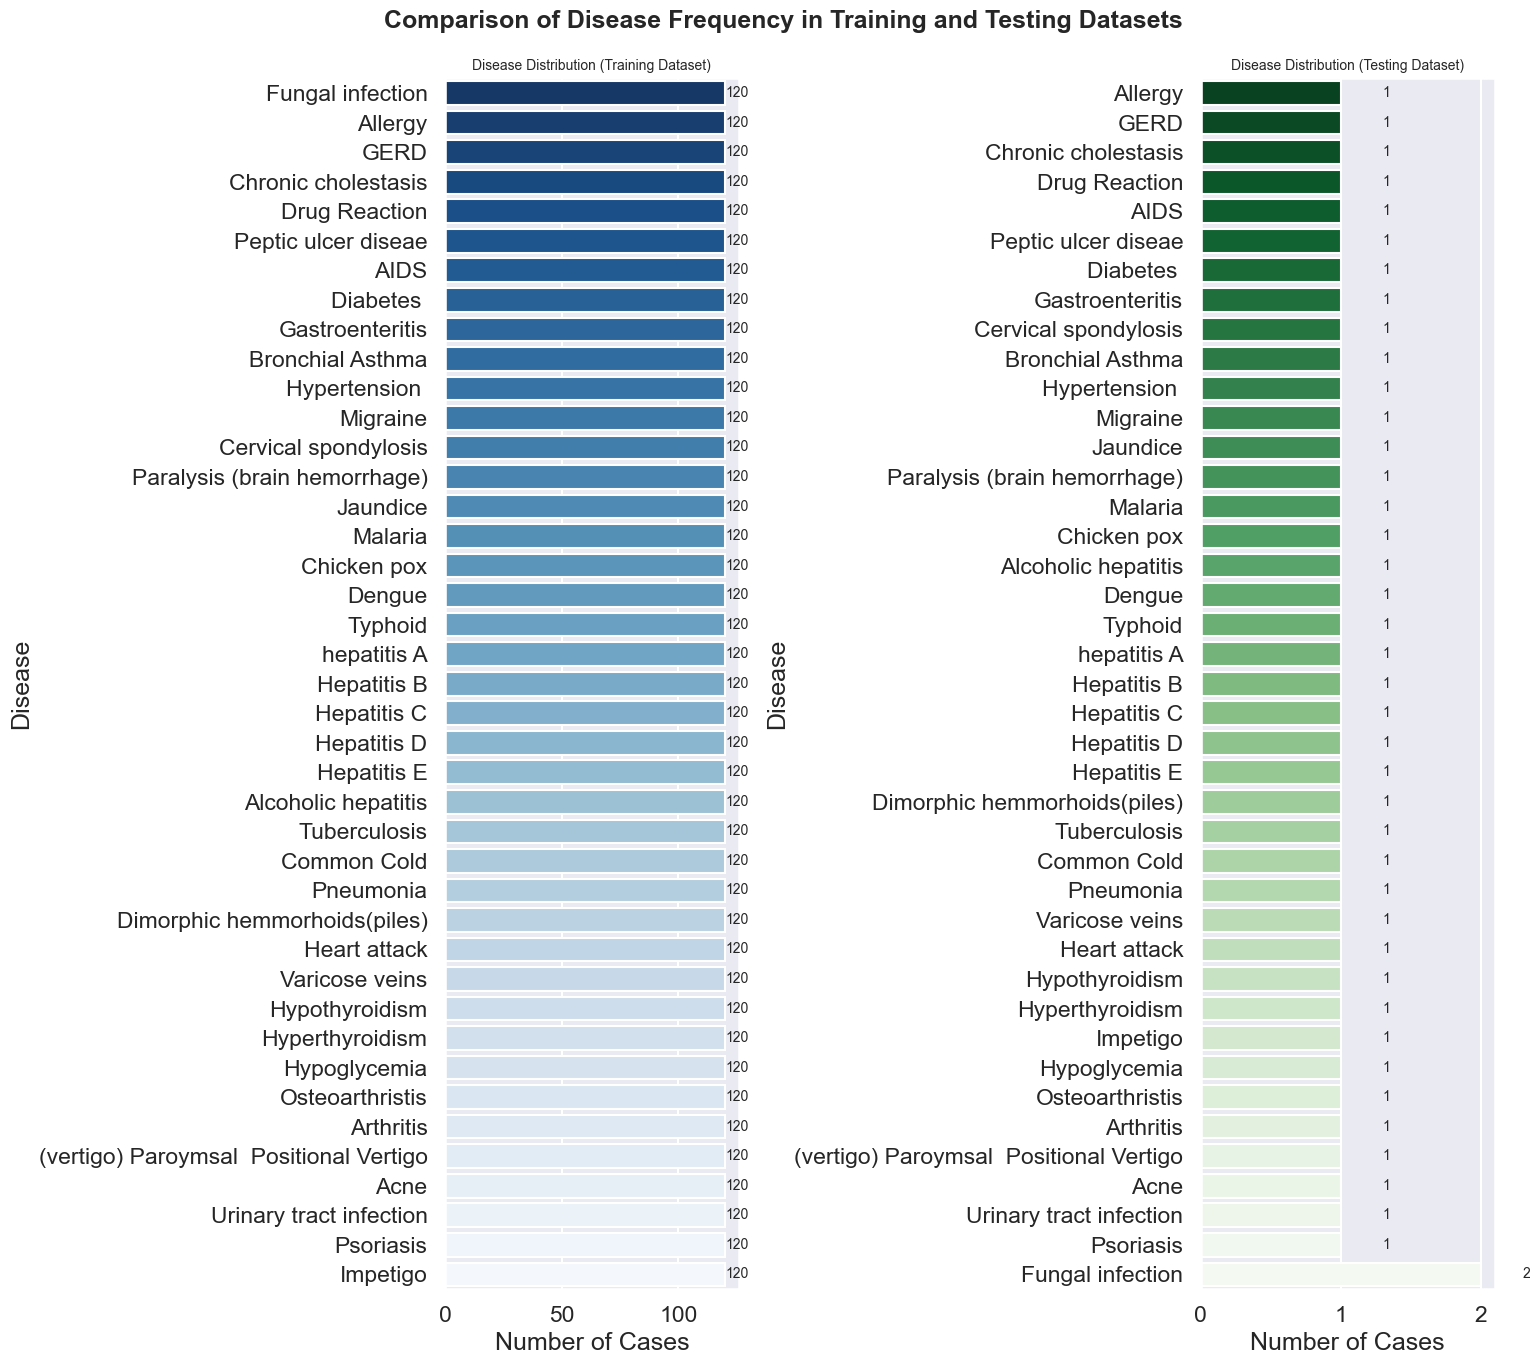

In [ ]:

sns.set_theme(style="darkgrid", context="talk")
# Compute disease counts
train_counts = train_df["prognosis"].value_counts().sort_values()
test_counts = test_df["prognosis"].value_counts().sort_values()
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16,14))
# Train dataset visualization
sns.barplot(
    x=train_counts.values,
    y=train_counts.index,
    palette="Blues_r",
    ax=axes[0]
)

axes[0].set_title("Disease Distribution (Training Dataset)", fontsize=10)
axes[0].set_xlabel("Number of Cases"),
axes[0].set_ylabel("Disease")
# Annotate values
for i, value in enumerate(train_counts.values):
    axes[0].text(value + 0.3, i, f"{value}", va="center", fontsize=10)
# Test dataset visualization
sns.barplot(
    x=test_counts.values,
    y=test_counts.index,
    palette="Greens_r",
    ax=axes[1]
)
axes[1].set_title("Disease Distribution (Testing Dataset)", fontsize=10)
axes[1].set_xlabel("Number of Cases")
axes[1].set_ylabel("Disease")

# Annotate values
for i, value in enumerate(test_counts.values):
    axes[1].text(value + 0.3, i, f"{value}", va="center", fontsize=10)

#  title
fig.suptitle(
    "Comparison of Disease Frequency in Training and Testing Datasets",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()
plt.show()

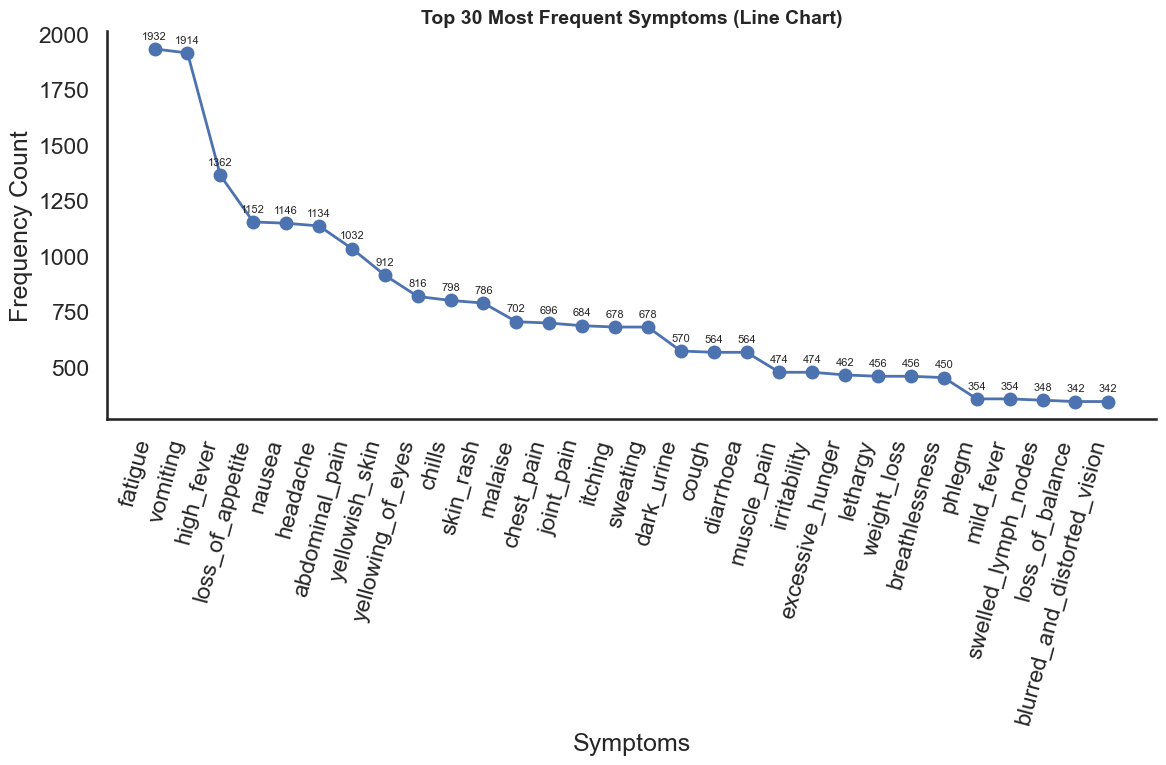

In [661]:
# Calculate symptom frequency
symptom_counts = train_df.drop(columns="prognosis").sum()
#select top 30
top_symptoms_line = symptom_counts.sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(
    top_symptoms_line.index,
    top_symptoms_line.values,
    marker="o",
    linewidth=2
)
ax.set_title("Top 30 Most Frequent Symptoms (Line Chart)", fontsize=14, weight="bold")
ax.set_xlabel("Symptoms")
ax.set_ylabel("Frequency Count")
# Add numbers 
for i, y in enumerate(top_symptoms_line.values):
    ax.annotate(
        f"{int(y)}",
        (i, y),
        textcoords="offset points",
        xytext=(0, 6),   # (x,y)
        ha="center",
        va="bottom",
        fontsize=8
    )
# Use numeric x positions to match the annotate loop
ax.set_xticks(range(len(top_symptoms_line.index)))
ax.set_xticklabels(top_symptoms_line.index, rotation=75, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

Symptom Frequency Analysis :The most frequently occurring symptoms were identified by summing each symptom column.
Visualization included:Top 30 most common symptoms Horizontal bar chart representation, This helps identify symptoms that strongly contribute to disease prediction

8. Feature Engineering

Machine learning models require numerical inputs.

In [635]:
X_train = train_df.drop(columns=['prognosis'])
X_test = test_df.drop(columns=['prognosis'])

In [636]:
#Target Variable
y_train = train_df['prognosis']
y_test = test_df['prognosis']

In [637]:

X_train = train_df.drop(columns=['prognosis'])
y_train = train_df['prognosis']

X_test = test_df.drop(columns=['prognosis'])
y_test= test_df['prognosis']

In [638]:
# Label Encoding Disease labels were converted into numeric format using LabelEncoder.

le = LabelEncoder()
y_train_encode = le.fit_transform(y_train)
y_test_encode = le.transform(y_test)

In [639]:
print(le.transform(["Fungal infection"]))

[15]


In [640]:
print(y_test.shape)
print(y_train.shape)

(42,)
(4920,)


9. Machine Learning Models

Two machine learning models were implemented in this file.

Model a):  Logistic Regression - Multinomial 
Logistic Regression is a widely used classification algorithm suitable for multi-class problems.

In [641]:
# Model configuration:
multinomial_model = LogisticRegression(
    #multi_class='multinomial', 
    solver='lbfgs',  ##lbfgs automatically uses multinomial for multi-class problems
    max_iter=1000, 
    C=1.0, 
    random_state=42
)
multinomial_model.fit(X_train, y_train_encode)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [642]:
# Predict & Evaluate
y_pred = multinomial_model.predict(X_test)

In [643]:
print("Accuracy:", accuracy_score(y_test_encode, y_pred))
print(classification_report(y_test_encode, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         1
          17 

This model serves as a baseline classifieThis dataset is known to give very high accuracy because symptoms map almost perfectly to diseases.The model achieved 100% accuracy on the testing dataset.
This is expected because the dataset contains clear symptom–disease relationships and a small test set.

Model B: Random Forest Classifier
Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions.

In [644]:
# Model initialization:
RandomForest_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [645]:
## Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    RandomForest_model,
    X_train,
    y_train_encode,
    cv=cv,
    scoring="accuracy"
)
print("CV scores:", cv_scores)
print("Mean CV:", cv_scores.mean())

CV scores: [1. 1. 1. 1. 1.]
Mean CV: 1.0


In [646]:
# Hyperparameter tuning using Grid Search

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
)
grid.fit(X_train, y_train_encode)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [647]:
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 1.0


In [648]:
# Final Model
best_RandomForest_model = grid.best_estimator_

y_pred_RandomForest = best_RandomForest_model.predict(X_test)


## Model Evaluation
print("Accuracy:", accuracy_score(y_test_encode, y_pred_RandomForest))
print(classification_report(y_test_encode, y_pred_RandomForest))

Accuracy: 0.9761904761904762
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      0.50      0.67         2
          16       1.00      1.00      1.00         

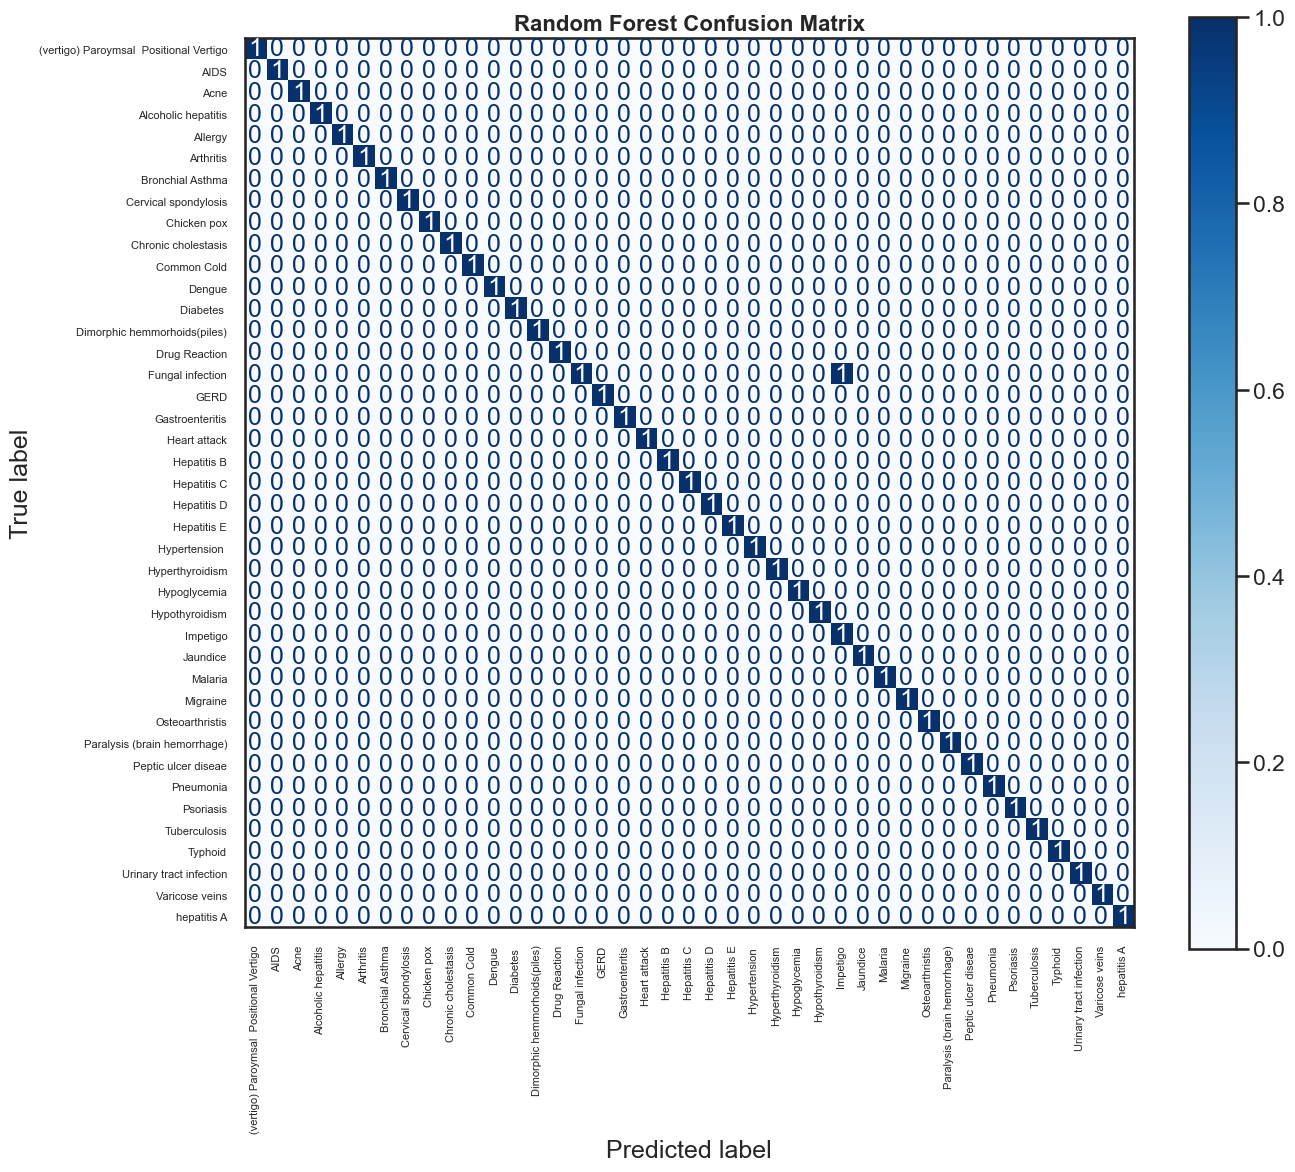

In [ ]:
fig, ax = plt.subplots(figsize=(14,12))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test_encode,
    y_pred_RandomForest,
    display_labels=le.classes_,
    cmap="Blues",
    ax=ax
)

ax.set_title("Random Forest Confusion Matrix", fontsize=16, weight="bold")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [650]:
display_labels=le.classes_

In [651]:
ConfusionMatrixDisplay.from_predictions(
    y_test_encode,
    y_pred_RandomForest,
    display_labels=le.classes_,
    cmap="Blues",
    ax=ax
)

13. Results

Both models  predicted diseases based on symptom inputs.

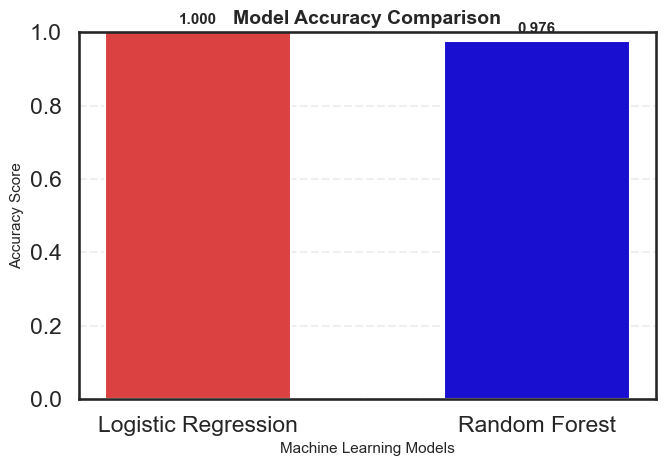

In [652]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

model_names = ["Logistic Regression", "Random Forest"]

accuracy_scores = [
    accuracy_score(y_test_encode, y_pred),
    accuracy_score(y_test_encode, y_pred_RandomForest)
]

fig, ax = plt.subplots(figsize=(7,5))
colors = ["#DB4141", "#180FD0"]

bars = ax.bar(
    model_names,
    accuracy_scores,
    color=colors,
    width=0.55
)

# Titles and labels
ax.set_title("Model Accuracy Comparison", fontsize=14, weight="bold")
ax.set_xlabel("Machine Learning Models", fontsize=11)
ax.set_ylabel("Accuracy Score", fontsize=11)

# Axis formatting
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Add Accuracy Labels on Bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

14. Key Insights

Binary symptom features provide strong predictive signals.Ensemble models perform better than linear models in complex datasets.
Cross-validation improves model reliability.

15. Limitations

Several limitations exist in the current project.
Symptoms are simplified into binary indicators.
Real-world medical diagnosis requires more detailed patient data.
Dataset size is relatively small.
Future work could include integrating additional medical features.

16. Conclusion

This research shows how symptom-based datasets can be used to forecast diseases using machine learning approaches. Classification models were developed and assessed following preprocessing and exploratory analysis.Because of its ensemble structure and capacity to handle high-dimensional data, the logistics regression model performed well.


Early disease identification, such systems could be helpful aids in healthcare settings.

Apendix  

Technologies Used
Tool	Purpose
Python	Programming language
Pandas	Data manipulation
NumPy	Numerical computing
Matplotlib / Seaborn	Data visualization
Scikit-learn	Machine learning models
Kaggle Dataset	Data source